## 1. Portfolio KPI Monitoring (MoM / Risk Trends)
This notebook simulates a lightweight retail-credit risk monitoring pack. A month-on-month (MoM) KPI analysis in credit decision analytics.

**Key ideas:**
- Generate 12 months of synthetic credit portfolio data (similar to a cards / personal-loan book)
- Calculate core risk KPIs (Bad rate 30+ DPD, early arrears 1+, approval rate, utilisation, vintage bad)
- Track MoM movements and highlight potential early warning signals
- Visualise key relationships: Early arrears vs Bad rate, Approval rate vs Bad rate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9,4)
plt.rcParams['axes.grid'] = True

## 2. Generate synthetic monthly portfolio data

We simulate a simplified cards / personal-loan portfolio with:
- Applications / approvals / declines
- Balances & limits
- 1+ DPD (early arrears) and 30+ DPD (bad bucket)
- New 30+ entries for a basic vintage view

In [3]:
# Synthetic raw data (12 months)
np.random.seed(42)

months = pd.date_range('2023-01-01', periods=12, freq='MS')
month_labels = months.strftime('%m-%Y')

# Applications between 2600 - 3400
applications = np.random.randint(2600, 3400, size=12)

# Approval rates between 58% and 78%, with a dip mid-year
base_app_rate = np.array([0.74,0.72,0.70,0.69,0.67,0.65,0.62,0.60,0.63,0.66,0.62,0.61])
noise = np.random.normal(0, 0.01, size=12)
approval_rate = np.clip(base_app_rate + noise, 0.55, 0.80)
approvals = (applications * approval_rate).astype(int)
declines = applications - approvals

# Balances and limits
balances = np.random.randint(11_000_000, 14_000_000, size=12)
limit_multipliers = np.random.uniform(1.7, 2.1, size=12)
limits = (balances * limit_multipliers).astype(int)

# Early arrears (1+ DPD) approx 6-8% of approvals, with some noise
early_pct = np.array([0.065,0.062,0.060,0.058,0.061,0.067,0.074,0.050,0.060,0.055,0.059,0.071])
dpd1 = (approvals * early_pct).astype(int)

# Bad bucket (30+ DPD) ~2.0-2.9% of accounts, correlated with early arrears
bad_pct = np.array([0.022,0.026,0.019,0.021,0.016,0.020,0.026,0.028,0.019,0.022,0.019,0.027])
dpd30 = (approvals * bad_pct).astype(int)

# New 30+ each month as a fraction of early arrears
new30 = (dpd1 * np.array([0.12,0.11,0.13,0.10,0.09,0.11,0.14,0.13,0.10,0.11,0.12,0.14])).astype(int)

raw = pd.DataFrame({
    'Month': month_labels,
    'Applications': applications,
    'Approvals': approvals,
    'Declines': declines,
    'Balances': balances,
    'Limits': limits,
    'DPD1': dpd1,
    'DPD30': dpd30,
    'New30+': new30
})
raw

,Month,Applications,Approvals,Declines,Balances,Limits,DPD1,DPD30,New30+
0,01-2023,2702,1945,757,13688875,28430160,126,42,15
1,02-2023,3035,2170,865,13416182,25830380,134,56,14
2,03-2023,2870,2020,850,13652991,25314919,121,38,15
3,04-2023,2706,1841,865,13370690,22815564,106,38,10
4,05-2023,2671,1791,880,13428388,24068472,109,28,9
5,06-2023,3300,2139,1161,11528178,20709336,143,42,15
6,07-2023,2620,1624,996,13663046,26961362,120,42,16
7,08-2023,3214,1914,1300,13586644,26412417,95,53,12
8,09-2023,2721,1699,1022,12305416,25020331,101,32,10
9,10-2023,3066,2019,1047,13570406,24010741,111,44,12


## 3. KPI calculations

We compute a small set of standard credit portfolio KPIs:
- **Approval Rate** = Approvals / Applications
- **Bad Rate (30+ DPD)** = DPD30 / Approvals
- **Early Arrears (1+ DPD)** = DPD1 / Approvals
- **Utilisation** = Balances / Limits
- **Vintage Bad (new 30+)** = New30+ / Approvals

In [ ]:
# KPI levels
kpi = raw.copy()

kpi['Approval_Rate']      = kpi['Approvals'] / kpi['Applications']
kpi['Bad_Rate_30+']       = kpi['DPD30']     / kpi['Approvals']
kpi['Early_Arrears_1+']   = kpi['DPD1']      / kpi['Approvals']
kpi['Utilisation']        = kpi['Balances']  / kpi['Limits']
kpi['Vintage_Bad_new30']  = kpi['New30+']    / kpi['Approvals']

kpi[['Month','Approval_Rate','Bad_Rate_30+','Early_Arrears_1+', 'Utilisation','Vintage_Bad_new30']]


## 4. Month-on-month (MoM) movements

For each rate-based KPI we compute a MoM % change:
MoM = Rate_t  / Rate_{t-1} -1

We also build a simple traffic-light flag:
- `RED` if MoM > +20% (deterioration),
- `GREEN` if MoM < -20% (improvement).

In [13]:
# MoM % changes
for col in ['Bad_Rate_30+','Early_Arrears_1+', 'Approval_Rate','Utilisation','Vintage_Bad_new30']:
    kpi[col + '_MoM'] = kpi[col].pct_change()

def flag_mom(x):
    if pd.isna(x):
        return ''
    if x > 0.20:
        return 'RED'
    if x < -0.20:
        return 'GREEN'
    return ''

# Apply flags to both Bad Rate and Early Arrears
kpi['Bad_Rate_Flag'] = kpi['Bad_Rate_30+_MoM'].apply(flag_mom)
kpi['Early_Arrears_1+_Flag'] = kpi['Early_Arrears_1+_MoM'].apply(flag_mom)

# Display combined monitoring table
kpi[['Month','Bad_Rate_30+','Bad_Rate_30+_MoM','Bad_Rate_Flag','Early_Arrears_1+','Early_Arrears_1+_MoM','Early_Arrears_1+_Flag']]


,Month,Bad_Rate_30+,Bad_Rate_30+_MoM,Bad_Rate_Flag,Early_Arrears_1+,Early_Arrears_1+_MoM,Early_Arrears_1+_Flag
0,01-2023,0.021594,NaN,,0.064781,NaN,
1,02-2023,0.025806,0.195084,,0.061751,-0.046778,
2,03-2023,0.018812,-0.271040,GREEN,0.059901,-0.029962,
3,04-2023,0.020641,0.097230,,0.057577,-0.038790,
4,05-2023,0.015634,-0.242587,GREEN,0.060860,0.057009,
5,06-2023,0.019635,0.255961,RED,0.066854,0.098486,
6,07-2023,0.025862,0.317118,RED,0.073892,0.105274,
7,08-2023,0.027691,0.070707,,0.049634,-0.328283,GREEN
8,09-2023,0.018835,-0.319822,GREEN,0.059447,0.197695,
9,10-2023,0.021793,0.157070,,0.054978,-0.075177,


## 5. Visuals

We focus on two standard overlays used in credit monitoring packs:
1. **Early Arrears vs Bad Rate** – does early stress (1+ DPD) propagate into 30+ DPD after a lag?
2. **Approval Rate vs Bad Rate** – is credit tightening / loosening feeding through into portfolio losses?

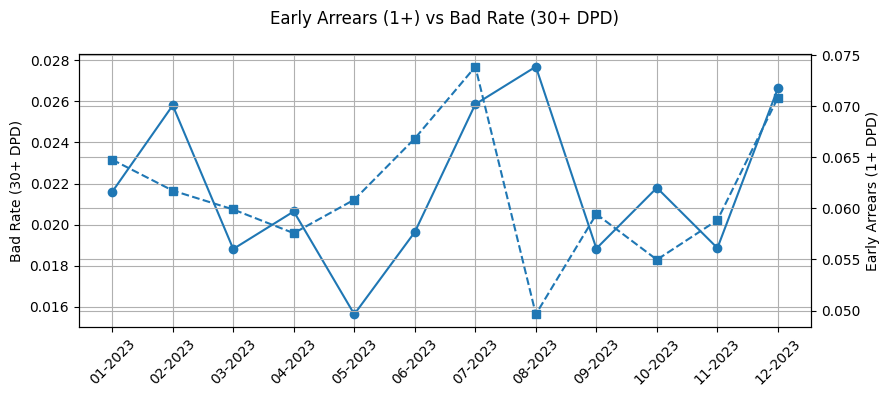

In [19]:
# Early Arrears vs Bad Rate (dual-axis)
fig, ax1 = plt.subplots()

x = np.arange(len(kpi))
ax1.plot(x, kpi['Bad_Rate_30+'], marker='o', label='Bad Rate (30+ DPD)')
ax1.set_ylabel('Bad Rate (30+ DPD)')
ax1.set_xticks(x)
ax1.set_xticklabels(kpi['Month'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, kpi['Early_Arrears_1+'], marker='s', linestyle='--', label='Early Arrears (1+ DPD)')
ax2.set_ylabel('Early Arrears (1+ DPD)')

fig.suptitle('Early Arrears (1+) vs Bad Rate (30+ DPD)')
fig.tight_layout()
plt.show()


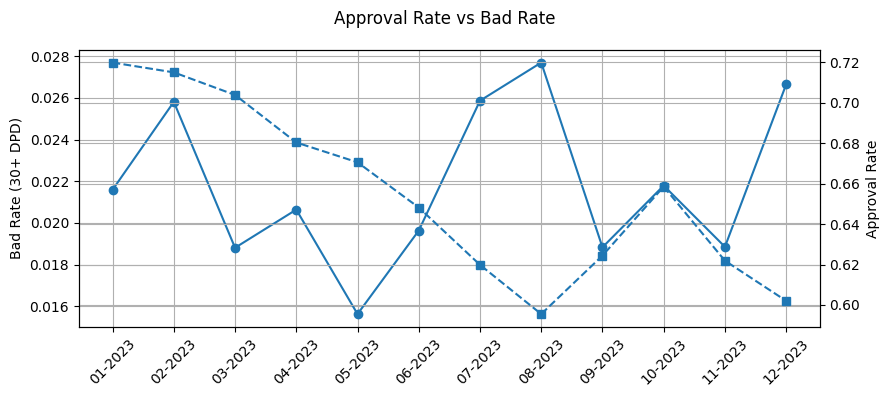

In [18]:
# Approval Rate vs Bad Rate (dual-axis)
fig, ax1 = plt.subplots()

x = np.arange(len(kpi))
ax1.plot(x, kpi['Bad_Rate_30+'], marker='o', label='Bad Rate (30+ DPD)')
ax1.set_ylabel('Bad Rate (30+ DPD)')
ax1.set_xticks(x)
ax1.set_xticklabels(kpi['Month'], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, kpi['Approval_Rate'], marker='s', linestyle='--', label='Approval Rate')
ax2.set_ylabel('Approval Rate')

fig.suptitle('Approval Rate vs Bad Rate')
fig.tight_layout()
plt.show()


## 6. Early-warning summary table

We create a compact table focused on risk signals:
- Month
- Bad rate level and MoM
- Early arrears level and MoM
- Traffic-light flag for bad rate.

In [17]:
summary_cols = [
    'Month',
    'Bad_Rate_30+', 'Bad_Rate_30+_MoM', 'Bad_Rate_Flag',
    'Early_Arrears_1+', 'Early_Arrears_1+_MoM', 'Early_Arrears_1+_Flag',
    'Approval_Rate', 'Approval_Rate_MoM']

summary = kpi[summary_cols].copy()
summary

,Month,Bad_Rate_30+,Bad_Rate_30+_MoM,Bad_Rate_Flag,Early_Arrears_1+,Early_Arrears_1+_MoM,Early_Arrears_1+_Flag,Approval_Rate,Approval_Rate_MoM
0,01-2023,0.021594,NaN,,0.064781,NaN,,0.719837,NaN
1,02-2023,0.025806,0.195084,,0.061751,-0.046778,,0.714992,-0.006731
2,03-2023,0.018812,-0.271040,GREEN,0.059901,-0.029962,,0.703833,-0.015607
3,04-2023,0.020641,0.097230,,0.057577,-0.038790,,0.680340,-0.033378
4,05-2023,0.015634,-0.242587,GREEN,0.060860,0.057009,,0.670535,-0.014411
5,06-2023,0.019635,0.255961,RED,0.066854,0.098486,,0.648182,-0.033337
6,07-2023,0.025862,0.317118,RED,0.073892,0.105274,,0.619847,-0.043714
7,08-2023,0.027691,0.070707,,0.049634,-0.328283,GREEN,0.595520,-0.039248
8,09-2023,0.018835,-0.319822,GREEN,0.059447,0.197695,,0.624403,0.048501
9,10-2023,0.021793,0.157070,,0.054978,-0.075177,,0.658513,0.054628


## 7. Insight summary

- Overall bad rate ranges roughly around 1.6–2.8%, with mid-year deterioration and partial recovery into year-end.
- Early arrears moves ahead of bad rate, with a noticeable hump mid-year that feeds into higher 30+ DPD shortly after.
- Approval rate tightens through mid-year (lower approvals), which is consistent with a risk-driven response to rising losses.
- Simple MoM flags (>+20% / <-20%) allow analysts to quickly highlight months needing drill-down.

In a production setting, this notebook would be extended by:
- Segmenting by product / risk band / channel
- Adding flow-through analysis (1+ → 30+ by vintage)
- Linking to strategy changes and macro indicators.
